<center>


<div style="display: flex; justify-content: center;">
    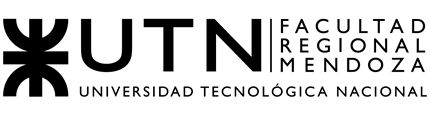
</div>
</center>
<center>
    <div style="font-family: 'Georgia', serif; font-size: 24px;">
        <p><strong>Análisis de Señales y Sistemas</strong></p>
        <p><strong>Ingeniería en Electrónica</strong></p>
        <p><strong>Ingeniería en Telecomunicaciones</strong></p>
    </div>
</center>

# Módulo 5 — Funciones

En los módulos anteriores aprendiste a trabajar con tipos de datos, colecciones y estructuras de control. Con lo que viste ya podés decidir y repetir. Este módulo agrega la tercera herramienta fundamental: **empaquetar** un trozo de código, ponerle un nombre y reutilizarlo cuantas veces haga falta.

Una **función** es una porción de código con nombre propio, que recibe datos de entrada (sus *parámetros*) y devuelve un resultado. Cada vez que la "llamás", Python ejecuta su bloque con los valores que le pasás. La idea está inspirada directamente en las funciones matemáticas — `f(x) = 2x + 1` — pero extendida: una función de Python puede recibir varios parámetros, hacer cualquier cosa por dentro, y devolver cero, uno o varios valores.

Los temas de este módulo son:

| Tema | Para qué sirve |
|------|----------------|
| `def` y `return` | Definir una función y devolver un resultado |
| Parámetros posicionales y con nombre | Distintas formas de pasar argumentos |
| Valores por defecto | Parámetros opcionales |
| Retorno múltiple | Devolver varios resultados de una vez |
| Composición | Una función que llama a otra |
| Alcance (*scope*) | Qué variables "ve" una función |
| Funciones como valores y `lambda` | Usar una función como argumento de otra |

## 1. Definición y llamada de una función

Una función se define con la palabra clave `def`, seguida del nombre, los parámetros entre paréntesis y dos puntos. El **cuerpo** va indentado debajo (4 espacios, igual que en los `if` y `for`).

```python
def nombre_de_la_funcion(parametro1, parametro2):
    # cuerpo de la función
    return resultado
```

- `def` le indica a Python que viene una definición de función.
- `parametro1`, `parametro2`: nombres que usás **dentro** del cuerpo para referirte a los valores que te pasen al llamarla.
- `return` devuelve un valor al lugar desde donde se llamó a la función. Si no hay `return`, la función igual funciona, pero devuelve `None`.

### Ejemplo: potencia eléctrica

Calcular la potencia disipada en una resistencia se hace con $P = V^2 / R$. Escribamos una función que haga esa cuenta:

In [ ]:
def potencia(v, r):
    return v**2 / r

# Llamamos a la función pasando valores concretos
print(potencia(5, 100))    # 5 V sobre 100 Ω → 0.25 W
print(potencia(12, 470))   # 12 V sobre 470 Ω → ~0.306 W

Separemos bien las dos cosas que pasan:

1. **Definición** (`def potencia(...)`): Python guarda la "receta" con el nombre `potencia`. En este punto **no se ejecuta** ningún cálculo todavía.
2. **Llamada** (`potencia(5, 100)`): Python agarra la receta, le entrega los valores `5` y `100` a los parámetros `v` y `r` respectivamente, ejecuta el cuerpo y devuelve el resultado.

Los nombres `v` y `r` solo existen **dentro** de la función. Afuera podés tener variables con otros nombres:

In [ ]:
tension = 9.0
resistencia = 220

p = potencia(tension, resistencia)
print(f"P = {p:.4f} W")

### Actividad 1: una función para la ley de Ohm

Escribí una función `corriente(v, r)` que, dadas una tensión en volts y una resistencia en ohms, devuelva la corriente en amperes según $I = V / R$.

1. Definí la función.
2. Calculá la corriente para $V = 5$ V y $R = 1000$ Ω; guardala en la variable `i1`.
3. Calculá la corriente para $V = 12$ V y $R = 470$ Ω; guardala en `i2`.
4. Mostrá ambos resultados con un f-string, en miliamperes, con dos decimales. Recordá que 1 A = 1000 mA.

In [ ]:
# TU CÓDIGO AQUÍ

## 2. Parámetros posicionales y con nombre

Cuando una función tiene varios parámetros, al llamarla podés pasar los argumentos de dos formas:

- **Por posición**: en el mismo orden en que fueron definidos.
- **Por nombre** (*keyword arguments*): indicando explícitamente a qué parámetro corresponde cada valor.

In [ ]:
def presentar(nombre, edad):
    print(f"Me llamo {nombre} y tengo {edad} años.")

# Por posición: nombre primero, edad después
presentar("Lucía", 25)

# Por nombre: el orden ya no importa
presentar(edad=30, nombre="Juan")

Pasar argumentos con nombre hace el código más legible cuando la función tiene varios parámetros, porque deja claro **qué significa** cada valor. Comparalo:

```python
filtrar(0.5, 1000, 8)      # ¿qué es cada número?
filtrar(umbral=0.5, fs=1000, orden=8)   # mucho más claro
```

También permite pasar los argumentos en cualquier orden.

## 3. Valores por defecto

Un parámetro puede tener un **valor por defecto**, que se usa si al llamar a la función no se especifica explícitamente. Así podés tener parámetros opcionales.

In [ ]:
def saludar(nombre="mundo"):
    print(f"¡Hola, {nombre}!")

saludar()           # Sin argumento: usa el valor por defecto
saludar("Marta")    # Con argumento: usa "Marta"

Los parámetros **sin** valor por defecto siempre deben ir **antes** que los que tienen valor por defecto. Es decir, primero los obligatorios, después los opcionales.

Ejemplo útil: una función que calcula la frecuencia de corte de un filtro RC. La resistencia típica en muchos circuitos es 1 kΩ, así que la ponemos como valor por defecto:

In [ ]:
def frecuencia_corte(c, r=1000):
    """Frecuencia de corte de un filtro RC (en Hz)."""
    return 1 / (2 * 3.14159 * r * c)

# Con resistencia por defecto (1 kΩ):
print(frecuencia_corte(1e-6))         # C = 1 µF
print(frecuencia_corte(c=10e-9))      # C = 10 nF (por nombre)

# Pasando también la resistencia:
print(frecuencia_corte(1e-6, 4700))   # C = 1 µF, R = 4.7 kΩ

> **Nota sobre el *docstring*.** El texto entre triples comillas al principio del cuerpo es una cadena que Python asocia a la función como su *documentación*. No altera el funcionamiento; sirve para que, al escribir `help(frecuencia_corte)` o al pasar el mouse por encima en el editor, aparezca esa explicación breve. Es una buena costumbre ponerlo.

### Actividad 2: divisor de tensión

Un divisor de tensión con dos resistencias $R_1$ y $R_2$ y tensión de entrada $V_{in}$ entrega una tensión de salida

$$V_{out} = V_{in} \cdot \frac{R_2}{R_1 + R_2}$$

1. Escribí una función `divisor_tension(v_in, r1, r2)` que devuelva $V_{out}$.
2. Agregale un valor por defecto de `r2=1000` (Ω), de modo que si no se especifica, se use 1 kΩ.
3. Calculá `v_out` para $V_{in} = 12$ V, $R_1 = 4700$ Ω, dejando $R_2$ con su valor por defecto. Mostralo con un f-string.
4. Volvé a calcularlo para los mismos valores de $V_{in}$ y $R_1$, pero con $R_2 = 2200$ Ω, pasando el argumento **por nombre**.

In [ ]:
# TU CÓDIGO AQUÍ

## 4. Retornar varios valores

Una función puede devolver **más de un valor** separándolos con comas en el `return`. Python los empaqueta automáticamente en una tupla.

In [ ]:
def estadisticos(muestras):
    media = sum(muestras) / len(muestras)
    menor = min(muestras)
    mayor = max(muestras)
    return media, menor, mayor

temperaturas = [18.5, 19.0, 20.1, 21.3, 20.8, 19.4]
resultado = estadisticos(temperaturas)
print(resultado)        # es una tupla con los tres valores
print(type(resultado))

Lo más cómodo es **desempacar** la tupla directamente en variables separadas al recibirla, así cada valor queda nombrado:

In [ ]:
m, lo, hi = estadisticos(temperaturas)
print(f"Media:  {m:.2f}")
print(f"Mínimo: {lo}")
print(f"Máximo: {hi}")

Este patrón — función que devuelve varios resultados, llamada que los desempaca — es muy común. Evita tener que hacer varias funciones separadas para cada resultado cuando todos salen del mismo cálculo.

### Actividad 3: amplitud pico a pico y promedio

Dada una lista de muestras, querés obtener en una sola llamada el **valor medio** y la **amplitud pico a pico** (la diferencia entre el máximo y el mínimo).

1. Escribí una función `medio_y_vpp(muestras)` que devuelva ambos valores.
2. Probala con la lista `[0.0, 0.3, 0.7, 1.1, 1.4, 1.2, 0.8, 0.4, 0.0, -0.3, -0.6]`.
3. Desempacá el resultado en dos variables `vm` y `vpp`, y mostralas con un f-string, con tres decimales cada una.

In [ ]:
muestras = [0.0, 0.3, 0.7, 1.1, 1.4, 1.2, 0.8, 0.4, 0.0, -0.3, -0.6]

# TU CÓDIGO AQUÍ

## 5. Funciones que llaman a otras funciones

Una vez definida una función, se puede usar desde adentro de otras funciones. Esto permite **construir soluciones complejas combinando piezas más simples**, que se pueden probar por separado.

Veamos un ejemplo con conversión de unidades de temperatura. Definimos dos funciones básicas:

In [ ]:
def celsius_a_kelvin(t_c):
    return t_c + 273.15

def kelvin_a_fahrenheit(t_k):
    return t_k * 9/5 - 459.67

print(celsius_a_kelvin(0))        # 273.15
print(kelvin_a_fahrenheit(300))   # ~80.33

Si ahora queremos convertir directamente de Celsius a Fahrenheit, no hace falta deducir la fórmula: podemos **combinar** las dos funciones anteriores.

In [ ]:
def celsius_a_fahrenheit(t_c):
    t_k = celsius_a_kelvin(t_c)
    return kelvin_a_fahrenheit(t_k)

print(celsius_a_fahrenheit(0))    # 32.0
print(celsius_a_fahrenheit(100))  # 212.0

Cada función hace una sola cosa y es fácil de verificar. Al combinarlas, obtenemos una nueva función más compleja sin repetir código ni complicar la lógica. Este estilo — **descomponer** un problema grande en funciones chicas y bien nombradas — es una de las herramientas más potentes para escribir código que se entienda y se pueda mantener.

### Actividad 4: potencia en decibeles

La potencia en decibeles relativa a una referencia de 1 mW se calcula como

$$P_{dBm} = 10 \cdot \log_{10}(P / 1\,\text{mW})$$

Ya tenés la función `potencia(v, r)` de la sección 1. Ahora necesitás otra función que, dada una potencia en watts, devuelva su valor en dBm.

1. Importá `log10` con `from math import log10`.
2. Escribí una función `a_dbm(p_watts)` que devuelva la potencia en dBm. Pista: 1 mW = 0.001 W.
3. Escribí una función `v_r_a_dbm(v, r)` que, dadas tensión y resistencia, devuelva la potencia disipada en dBm. Esta función debe **usar** `potencia(...)` y `a_dbm(...)`; no repitas la fórmula.
4. Verificá que `v_r_a_dbm(1, 1000)` da un valor cercano a 0 dBm (porque $1\,\text{V}^2 / 1\,\text{k}\Omega = 1\,\text{mW}$).

In [ ]:
from math import log10

def potencia(v, r):
    return v**2 / r

# TU CÓDIGO AQUÍ

## 6. Alcance de las variables (*scope*)

Cuando una función usa una variable, Python tiene que decidir **de dónde viene** esa variable. La regla es simple:

- Las variables definidas **dentro** de la función (incluyendo sus parámetros) son **locales**: solo existen mientras la función se está ejecutando, y no se ven desde afuera.
- Las variables definidas **fuera** de cualquier función son **globales**: se pueden leer desde adentro de las funciones, pero por defecto no se pueden modificar.

### Variable local

In [ ]:
def calcular():
    resultado = 42   # variable local: nace y muere dentro de la función
    print(resultado)

calcular()
# print(resultado)   # ← si descomentás esta línea, da NameError:
                     #   resultado no existe fuera de la función

### Lectura de una variable global

In [ ]:
tension_alimentacion = 5.0   # global

def mostrar_alimentacion():
    print(f"Vcc = {tension_alimentacion} V")   # la lee desde adentro

mostrar_alimentacion()

### Recomendación

Mezclar lecturas de variables globales dentro de funciones es cómodo al principio, pero hace que las funciones dejen de ser **autocontenidas**: el resultado depende de cosas que están afuera, y se vuelve más difícil razonar sobre qué hace cada pieza.

La convención sana es: **todo lo que la función necesita, recibirlo como parámetro; todo lo que produce, devolverlo con `return`**. Así cada función es independiente, reutilizable y fácil de testear.

## 7. Funciones como valores y funciones `lambda`

En Python, las funciones son **valores**: podés asignarlas a una variable, guardarlas en una lista o pasarlas como argumento a otra función, exactamente como con un número o una string.

In [ ]:
def duplicar(x):
    return 2 * x

# Asignamos la función (sin paréntesis) a otro nombre
f = duplicar
print(f(10))   # 20

Fijate que `duplicar` (sin paréntesis) se refiere a la función en sí; `duplicar(10)` sería llamarla. Al asignar `f = duplicar`, ambos nombres apuntan a la misma función.

### Funciones `lambda`

Cuando necesitás una función **muy corta y para un solo uso**, es tedioso escribir un `def` completo. Python ofrece una sintaxis compacta llamada `lambda`:

```python
lambda parametros: expresion
```

Una `lambda` define una función anónima de una sola expresión. Estas dos formas son equivalentes:

In [ ]:
# Con def
def cuadrado(x):
    return x**2

# Con lambda
cuadrado_l = lambda x: x**2

print(cuadrado(5), cuadrado_l(5))

### Uso típico: pasar una función como argumento

El caso más frecuente de `lambda` es pasarla como argumento a otra función que espera una función. Por ejemplo, `sorted(...)` acepta un parámetro `key=` que le indica **según qué criterio** ordenar.

In [ ]:
componentes = [
    {"nombre": "R1", "valor": 220},
    {"nombre": "R2", "valor": 1000},
    {"nombre": "R3", "valor": 47},
    {"nombre": "R4", "valor": 4700},
]

# Ordenar por el valor de resistencia, de menor a mayor
ordenados = sorted(componentes, key=lambda comp: comp["valor"])

for c in ordenados:
    print(c)

La `lambda comp: comp["valor"]` es una función chiquita que, dado un componente, devuelve su clave `"valor"`. Por otro lado `sorted()` la llama sobre cada elemento para decidir el orden. Para algo tan corto y local, definir una función con `def` sería exagerado.

> **Cuándo usar `lambda`.** Sirve para expresiones **simples** y **únicas**, típicamente como `key` de `sorted()`, `max()`, `min()`, o `filter()`. Si la lógica es larga o se usa en varios lugares, mejor una función definida con `def`, que puede tener nombre claro, varias líneas y hasta *docstring*.

### Actividad 5: ordenar señales por amplitud

Tenés una lista de señales, cada una representada como un diccionario con un nombre y una lista de muestras:

```python
senales = [
    {"nombre": "s1", "muestras": [0.1, -0.2, 0.3, 0.0, -0.1]},
    {"nombre": "s2", "muestras": [1.0, -1.2, 0.8, -0.9, 1.1]},
    {"nombre": "s3", "muestras": [0.5, -0.6, 0.4, -0.3, 0.7]},
]
```

1. Usá `sorted(...)` con una `lambda` para ordenar la lista **de mayor a menor** según la **amplitud pico a pico** de las muestras (la diferencia entre `max` y `min`). Pista: para ordenar descendente pasale `reverse=True` a `sorted`.
2. Recorré la lista ordenada con un `for` y mostrá, por cada señal, su nombre y su amplitud pico a pico con un f-string, con dos decimales.

In [ ]:
senales = [
    {"nombre": "s1", "muestras": [0.1, -0.2, 0.3, 0.0, -0.1]},
    {"nombre": "s2", "muestras": [1.0, -1.2, 0.8, -0.9, 1.1]},
    {"nombre": "s3", "muestras": [0.5, -0.6, 0.4, -0.3, 0.7]},
]

# TU CÓDIGO AQUÍ

## Cierre

En este módulo viste cómo empaquetar código en unidades reutilizables:

- **`def` y `return`**: la forma básica de definir una función y devolver un resultado.
- **Parámetros posicionales y con nombre**: dos maneras de pasar los argumentos al llamar; los *keyword arguments* hacen el código más legible.
- **Valores por defecto**: parámetros opcionales que no hace falta especificar en cada llamada.
- **Retorno múltiple**: devolver varios valores separados por coma; el receptor los desempaca en variables independientes.
- **Composición**: combinar funciones chicas para construir otras más grandes sin repetir código.
- **Alcance**: las variables locales viven solo dentro de la función. Preferir pasar todo por parámetro y devolver con `return`.
- **Funciones como valores y `lambda`**: una función puede usarse como dato y pasarse a otra función; `lambda` es la forma compacta para expresiones de una sola línea.

Con funciones dejás de repetir el mismo bloque de código una y otra vez: definís una vez, probás una vez, y después lo usás cuantas veces haga falta.

**En el próximo módulo** vamos a ver una idea emparentada pero más potente: **clases y objetos**. Una clase permite agrupar datos y las funciones que operan sobre esos datos en una sola unidad. Es la base de la *programación orientada a objetos*, y vas a reconocer su sintaxis cuando más adelante uses librerías como NumPy, Matplotlib o SciPy.